# 03 — Exploratory data analysis

EDA on the processed dataset (`data/processed/all_sites_daily.csv`, built by
`src/clean_data.py`): summary statistics, the seasonal cycle and the north–south
gradient, GHI distributions by season, correlations between GHI and its
meteorological drivers (RQ2 groundwork), interannual variability, and
consecutive low-sun-day runs (groundwork for the RQ4 off-grid sizing model).
Seasonal/zonal contrasts here are the groundwork for RQ3. All figures are saved
to `results/figures/` for the interim report.

In [1]:
from google.colab import drive           # imports the drive module from Google Colab
drive.mount('/content/drive')            # mounts Google Drive to the Colab environment

Mounted at /content/drive


In [2]:
BASE_PATH_NAME='/content/drive/MyDrive/Colab-Notebooks/Msc-Capstone-Project'

In [3]:
import sys, warnings
sys.path.append(BASE_PATH_NAME+'/src')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config import (SITES, PARAMETERS, START, END, DATA_RAW, DATA_PROCESSED,
                    RESULTS, TRAIN_END, VAL_END)

TARGET = 'ALLSKY_SFC_SW_DWN'
FIGDIR = RESULTS / 'figures'
FIGDIR.mkdir(parents=True, exist_ok=True)

# Sites ordered north -> south; fixed colour per site (Okabe-Ito subset,
# colour-blind-safe; validated for adjacent-pair CVD separation).
SITE_ORDER = ['navrongo', 'tamale', 'kumasi', 'accra', 'takoradi']
SITE_COLOR = {'navrongo': '#D55E00', 'tamale': '#0072B2', 'kumasi': '#009E73',
              'accra': '#E69F00', 'takoradi': '#CC79A7'}
SITE_LABEL = {k: SITES[k]['name'] for k in SITES}

plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 200, 'savefig.bbox': 'tight',
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': 0.25, 'axes.axisbelow': True})


In [4]:
df = pd.read_csv(DATA_PROCESSED / 'all_sites_daily.csv', parse_dates=['date'])
df = df.set_index('date')
SEASON_ORDER = ['harmattan_dry', 'major_wet', 'minor_dry', 'minor_wet']
SEASON_LABEL = {'harmattan_dry': 'Harmattan dry\n(Dec–Feb)', 'major_wet': 'Major wet\n(Mar–Jun)',
                'minor_dry': 'Minor dry\n(Jul–Aug)', 'minor_wet': 'Minor wet\n(Sep–Nov)'}
print(df.shape)
df.head(3)

(36525, 21)


,ALLSKY_SFC_SW_DWN,T2M,RH2M,CLOUD_AMT,PRECTOTCORR,WS2M,site,zone,doy_sin,doy_cos,...,season,ghi_lag1,ghi_lag2,ghi_lag3,ghi_lag4,ghi_lag5,ghi_lag6,ghi_lag7,ghi_roll7,ghi_roll30
date,,,,,,,,,,,,,,,,,,,,,
2005-01-01,5.2625,26.82,85.64,47.32,5.05,1.76,accra,coastal_savannah,0.017202,0.999852,...,harmattan_dry,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-01-02,5.8656,26.32,71.60,12.33,1.08,2.12,accra,coastal_savannah,0.034398,0.999408,...,harmattan_dry,5.2625,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-01-03,5.7005,26.75,77.16,1.61,0.01,1.35,accra,coastal_savannah,0.051584,0.998669,...,harmattan_dry,5.8656,5.2625,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3.1 Summary statistics (GHI, kWh/m²/day)

In [5]:
stats = []
for key in SITE_ORDER:
    s = df.loc[df['site'] == key, TARGET]
    stats.append({'Site': SITE_LABEL[key], 'Zone': SITES[key]['zone'], 'N days': int(s.notna().sum()),
                  'Mean': s.mean(), 'Std': s.std(), 'Min': s.min(),
                  'P5': s.quantile(0.05), 'Median': s.median(), 'P95': s.quantile(0.95), 'Max': s.max()})
summary = pd.DataFrame(stats).round(2)
summary.to_csv(RESULTS / 'eda_summary_stats.csv', index=False)
summary

,Site,Zone,N days,Mean,Std,Min,P5,Median,P95,Max
0,Navrongo,sudan_savannah,7305,5.53,1.00,0.74,3.49,5.73,6.80,7.71
1,Tamale,guinea_savannah,7305,5.25,0.98,0.65,3.28,5.43,6.53,7.30
2,Kumasi,forest,7305,4.71,0.82,1.29,3.26,4.77,5.97,7.06
3,Accra,coastal_savannah,7305,4.89,0.94,0.51,3.05,5.07,6.16,7.13
4,Takoradi,coastal,7305,4.96,1.09,0.54,2.79,5.16,6.35,7.11


**Interpretation.** Mean daily GHI follows the expected north–south gradient:
Navrongo 5.53 > Tamale 5.25 kWh/m²/day in the savannah north, versus 4.71–4.96 in the
south — with the moist-forest site (Kumasi, 4.71) the least sunny, not the coast.
Takoradi is the most *variable* site (SD = 1.09; 5th percentile 2.79 kWh/m²/day, the
lowest of the five), a first hint that coastal cloudiness — not average resource — is
the binding constraint for both forecasting difficulty and off-grid sizing.

## 3.2 Driver summary statistics (univariate)

The five meteorological drivers get the same univariate treatment as the target,
per site over the full 2005–2024 record.

In [6]:
drivers = [p for p in PARAMETERS if p != TARGET]
rows = []
for key in SITE_ORDER:
    sub = df[df['site'] == key]
    for p in drivers:
        s = sub[p]
        rows.append({'Site': SITE_LABEL[key], 'Variable': p, 'Mean': s.mean(),
                     'SD': s.std(), 'Min': s.min(), 'Median': s.median(), 'Max': s.max()})
driver_stats = pd.DataFrame(rows).round(2)
driver_stats.to_csv(RESULTS / 'eda_driver_summary_stats.csv', index=False)
driver_stats.pivot(index='Variable', columns='Site', values='Mean').round(1)

Site,Accra,Kumasi,Navrongo,Takoradi,Tamale
Variable,,,,,
CLOUD_AMT,59.8,65.9,51.6,56.2,55.0
PRECTOTCORR,3.4,4.3,3.0,4.3,3.0
RH2M,84.8,81.3,58.0,84.9,67.2
T2M,26.6,25.7,27.6,26.2,27.3
WS2M,2.7,1.6,2.2,1.8,2.0


**Interpretation.** The driver statistics quantify the climatic contrast behind the zones. Mean cloud amount is highest at the forest site (Kumasi, 66%) and lowest at Navrongo (52%), while mean relative humidity separates the regimes most sharply: 85% at the coastal sites versus 58% at Navrongo, and with far larger day-to-day variability in the north (RH SD 24 points at Navrongo versus 5 at Accra/Takoradi, reflecting the alternation between humid monsoon flow and dry Harmattan air). Rainfall means are highest at Kumasi and Takoradi (4.3 mm/day), and winds are light everywhere (means 1.6–2.7 m/s). These figures complete the univariate picture required before any bivariate claim, and they flag one modeling caution: the north's wide humidity range gives tree models a usable regime signal that coastal sites lack. Full table saved as results/eda_driver_summary_stats.csv.

## 3.3 Univariate GHI distributions (Figure 3-6)

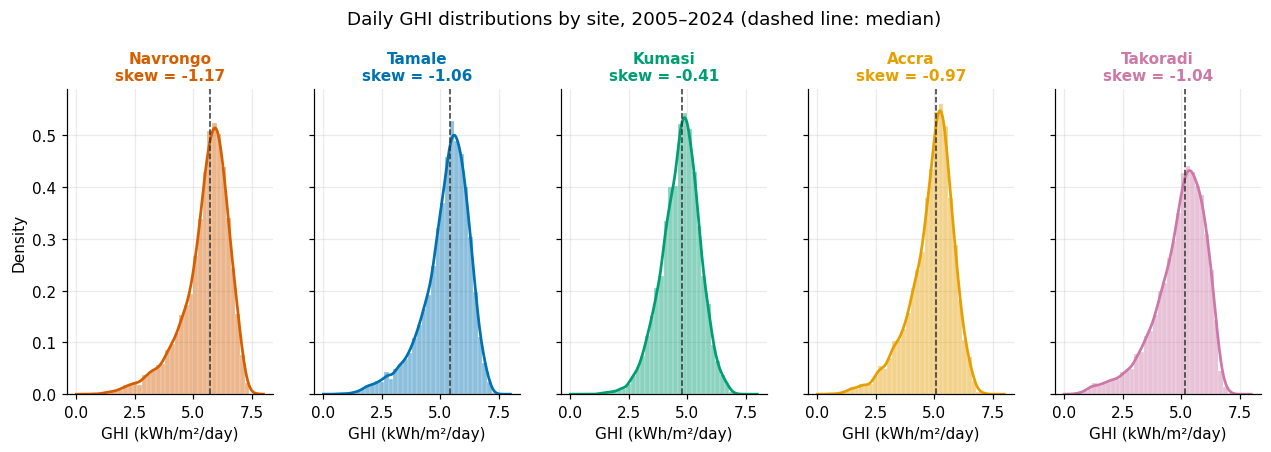

{'navrongo': -1.17, 'tamale': -1.06, 'kumasi': -0.41, 'accra': -0.97, 'takoradi': -1.04}


In [7]:
from scipy.stats import gaussian_kde, skew

fig, axes = plt.subplots(1, 5, figsize=(14, 3.6), sharey=True, sharex=True)
skews = {}
for ax, key in zip(axes, SITE_ORDER):
    s = df.loc[df['site'] == key, TARGET].dropna()
    skews[key] = float(skew(s))
    ax.hist(s, bins=40, range=(0, 8), density=True, color=SITE_COLOR[key],
            alpha=0.45, edgecolor='white', linewidth=0.3)
    xs = np.linspace(0, 8, 200)
    ax.plot(xs, gaussian_kde(s)(xs), color=SITE_COLOR[key], lw=1.8)
    ax.axvline(s.median(), color='#333', lw=1, ls='--')
    ax.set_title(f"{SITE_LABEL[key]}\nskew = {skews[key]:.2f}", fontsize=10,
                 color=SITE_COLOR[key], fontweight='bold')
    ax.set_xlabel('GHI (kWh/m²/day)')
axes[0].set_ylabel('Density')
fig.suptitle('Daily GHI distributions by site, 2005–2024 (dashed line: median)', y=1.08)
fig.savefig(FIGDIR / 'fig_03_6_ghi_histograms.png')
plt.show()
print({k: round(v, 2) for k, v in skews.items()})

**Interpretation (Figure 3-6).** Every site is left-skewed: the typical day sits near 5–6 kWh/m²/day and the risk is concentrated in a long lower tail of cloudy days. Skewness strengthens from the forest (Kumasi, −0.41, the most symmetric and narrowest distribution) to the savannah and coastal sites (Accra −0.97, Takoradi −1.04, Tamale −1.06, Navrongo −1.17). Two implications follow. For forecasting (RQ1), symmetric error metrics such as RMSE are dominated by these tail days, so models that only track the seasonal mean will look adequate on average while missing exactly the days that matter; this is where ML anomaly skill must come from. For sizing (RQ4), the mean overstates the dependable resource, so reliability-constrained design must be driven by the lower tail rather than the average, which is precisely what the LOLP simulation does.

## 3.4 Seasonal cycle — monthly climatology (Figure 3-1)

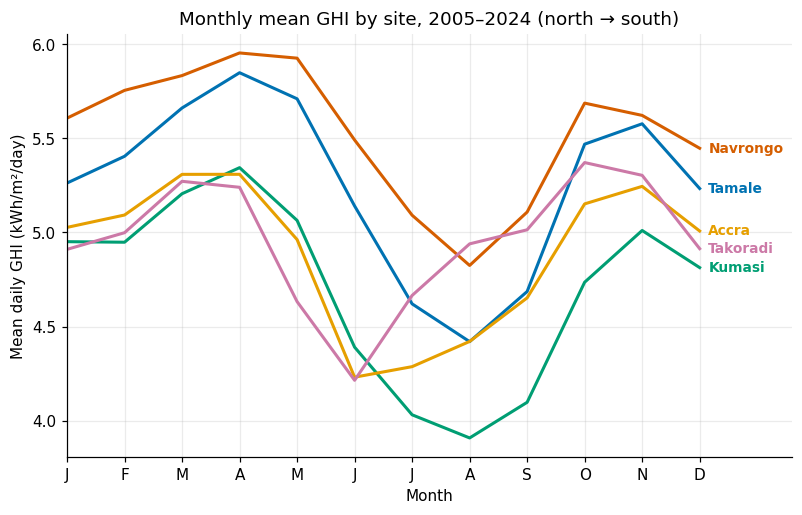

In [8]:
fig, ax = plt.subplots(figsize=(8.5, 5))
monthly = (df.groupby(['site', df.index.month])[TARGET].mean()
             .rename_axis(['site', 'month']).reset_index())
for key in SITE_ORDER:
    m = monthly[monthly['site'] == key]
    ax.plot(m['month'], m[TARGET], color=SITE_COLOR[key], lw=2)
    ax.annotate(SITE_LABEL[key], xy=(12, m[TARGET].iloc[-1]), xytext=(12.15, m[TARGET].iloc[-1]),
                color=SITE_COLOR[key], fontsize=9, fontweight='bold', va='center')
ax.set_xticks(range(1, 13)); ax.set_xticklabels(list('JFMAMJJASOND'))
ax.set_xlim(1, 13.6)
ax.set_xlabel('Month'); ax.set_ylabel('Mean daily GHI (kWh/m²/day)')
ax.set_title('Monthly mean GHI by site, 2005–2024 (north → south)')
fig.savefig(FIGDIR / 'fig_03_1_monthly_climatology.png')
plt.show()

**Interpretation (Figure 3-1).** All five sites share a bimodal cycle with a
mid-year minimum, but its depth differs sharply by zone. The northern savannah sites
peak in March–May (Navrongo ≈ 5.8–6.0 kWh/m²/day) and dip only to ≈ 4.8 in the
July–August monsoon, while the southern sites fall much further (Kumasi bottoms at
≈ 3.9 in August; Accra/Takoradi ≈ 4.2 in June). The ≈ 0.6–1.0 kWh/m²/day
gap between Navrongo and Kumasi that persists through the year is the north–south gradient RQ3
stratifies over. Note the Harmattan months (Dec–Feb) remain relatively sunny at all
sites — dust attenuation moderates but does not remove the dry-season advantage.

## 3.5 GHI distribution by season (Figure 3-2)

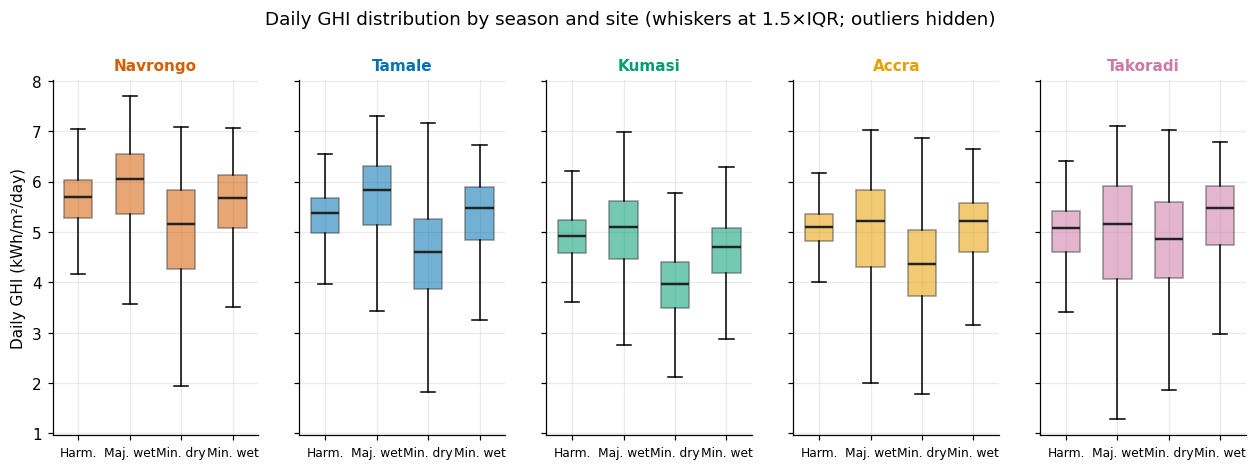

In [9]:
fig, axes = plt.subplots(1, 5, figsize=(14, 4.2), sharey=True)
for ax, key in zip(axes, SITE_ORDER):
    data = [df.loc[(df['site'] == key) & (df['season'] == s), TARGET].dropna() for s in SEASON_ORDER]
    bp = ax.boxplot(data, patch_artist=True, widths=0.55, showfliers=False)
    for patch in bp['boxes']:
        patch.set_facecolor(SITE_COLOR[key]); patch.set_alpha(0.55); patch.set_edgecolor('#444')
    for med in bp['medians']:
        med.set_color('#222'); med.set_linewidth(1.6)
    ax.set_xticklabels(['Harm.', 'Maj. wet', 'Min. dry', 'Min. wet'], fontsize=8)
    ax.set_title(SITE_LABEL[key], color=SITE_COLOR[key], fontweight='bold', fontsize=10)
axes[0].set_ylabel('Daily GHI (kWh/m²/day)')
fig.suptitle('Daily GHI distribution by season and site (whiskers at 1.5×IQR; outliers hidden)', y=1.03)
fig.savefig(FIGDIR / 'fig_03_2_seasonal_boxplots.png')
plt.show()

**Interpretation (Figure 3-2).** Seasonal contrast grows from north to south. At
Navrongo/Tamale the four seasonal distributions overlap heavily and medians stay above
5 kWh/m²/day except in the minor-dry (Jul–Aug) trough; at Kumasi, Accra and Takoradi
the minor-dry and major-wet boxes shift visibly downward and widen, with the coastal
sites showing the longest lower tails. For RQ3 this predicts that forecast errors will
be season-dependent mainly in the south; for RQ4 it shows the wet-season floor — not
the annual mean — is what a reliability-constrained system must be sized against.

## 3.6 Meteorological drivers — correlation with GHI (Figure 3-3, RQ2 groundwork)

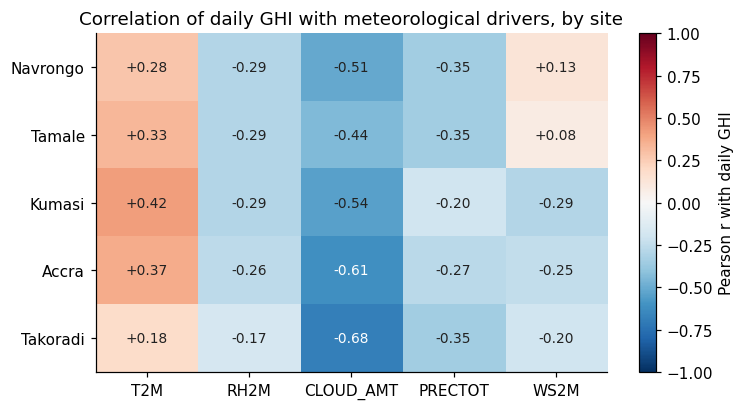

In [10]:
drivers = [p for p in PARAMETERS if p != TARGET]
corr = pd.DataFrame(index=[SITE_LABEL[k] for k in SITE_ORDER], columns=drivers, dtype=float)
for key in SITE_ORDER:
    sub = df[df['site'] == key]
    for p in drivers:
        corr.loc[SITE_LABEL[key], p] = sub[TARGET].corr(sub[p])
corr = corr.astype(float).round(2)
corr.to_csv(RESULTS / 'eda_driver_correlations.csv')

fig, ax = plt.subplots(figsize=(7.5, 4))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(drivers)))
ax.set_xticklabels(['T2M', 'RH2M', 'CLOUD_AMT', 'PRECTOT', 'WS2M'])
ax.set_yticks(range(len(corr.index))); ax.set_yticklabels(corr.index)
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        v = corr.values[i, j]
        ax.text(j, i, f'{v:+.2f}', ha='center', va='center', fontsize=9,
                color='white' if abs(v) > 0.55 else '#222')
ax.grid(False)
fig.colorbar(im, ax=ax, label='Pearson r with daily GHI')
ax.set_title('Correlation of daily GHI with meteorological drivers, by site')
fig.savefig(FIGDIR / 'fig_03_3_driver_correlations.png')
plt.show()

**Interpretation (Figure 3-3, RQ2 groundwork).** Cloud amount is the dominant
(negative) driver at every site, and its grip strengthens toward the coast: r = −0.44
at Tamale but −0.68 at Takoradi. Precipitation and relative humidity add moderate
negative associations (r ≈ −0.17 to −0.35), and temperature is moderately positive
(clear days are hot days; r = 0.18–0.42). Wind speed is the only sign-flipping
driver — weakly positive in the north (r = +0.08/+0.13, consistent with dry Harmattan
airflow) but negative in the south (−0.20 to −0.29, consistent with onshore/monsoon
flow bringing cloud). These orderings are the prior expectation the SHAP analysis in
notebook 06 will test formally (correlation here is association, not importance).

## 3.7 GHI versus cloud amount (Figure 3-7, bivariate)

Cloud amount is the dominant correlate identified in §3.6; the scatter shows the
shape of that relationship, with a locally weighted (LOWESS) trend per site.

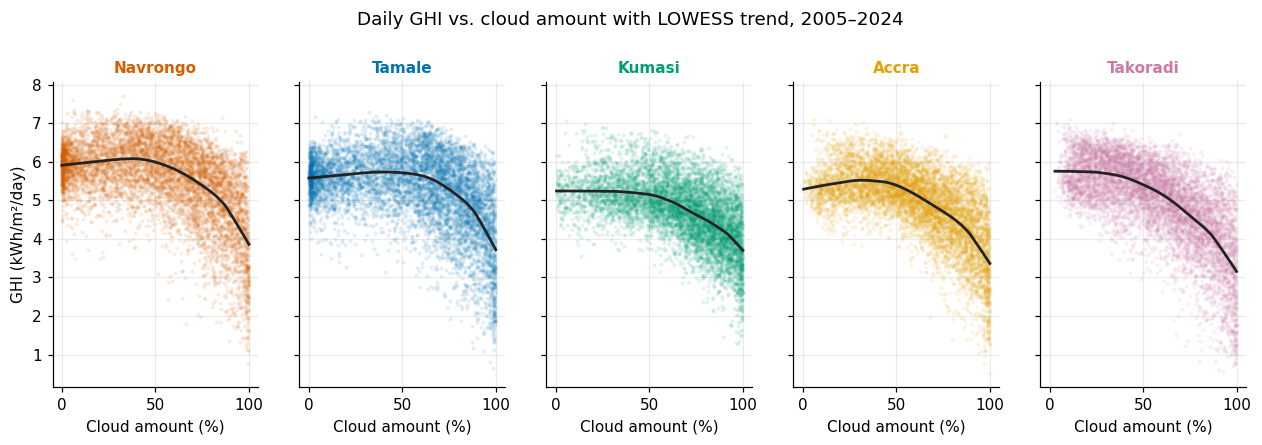

In [11]:
from statsmodels.nonparametric.smoothers_lowess import lowess

fig, axes = plt.subplots(1, 5, figsize=(14, 3.6), sharey=True, sharex=True)
for ax, key in zip(axes, SITE_ORDER):
    sub = df[df['site'] == key]
    ax.scatter(sub['CLOUD_AMT'], sub[TARGET], s=3, alpha=0.08, color=SITE_COLOR[key],
               rasterized=True)
    lw_xy = lowess(sub[TARGET], sub['CLOUD_AMT'], frac=0.3, return_sorted=True)
    ax.plot(lw_xy[:, 0], lw_xy[:, 1], color='#222222', lw=1.8)
    ax.set_title(SITE_LABEL[key], fontsize=10, color=SITE_COLOR[key], fontweight='bold')
    ax.set_xlabel('Cloud amount (%)')
axes[0].set_ylabel('GHI (kWh/m²/day)')
fig.suptitle('Daily GHI vs. cloud amount with LOWESS trend, 2005–2024', y=1.06)
fig.savefig(FIGDIR / 'fig_03_7_ghi_vs_cloud.png')
plt.show()

**Interpretation (Figure 3-7).** The relationship between cloud amount and GHI is clearly nonlinear at all five sites: the LOWESS trend is nearly flat up to roughly 40–50% cloud cover, then falls steeply, and the vertical spread widens as skies cloud over. Linear correlation (§3.6) therefore understates the strength of the association; the effective signal is closer to a threshold effect. This shape has two consequences. It is direct empirical justification for the choice of nonlinear tree-ensemble models over linear regression for RQ1, and it explains why the coastal sites are the hardest to forecast: they spend far more days in the steep, high-variance region of the curve. It also sharpens the RQ2 expectation that SHAP values for cloud amount will be concentrated on high-cloud days rather than spread uniformly.

## 3.8 Pairwise relationships among all variables (Figure 3-9)

A seaborn pair plot of the target and all five drivers, colored by site, gives the
full univariate-diagonal + bivariate-grid view in one figure and screens for
multicollinearity among the predictors (VIF screening is planned for RQ2).

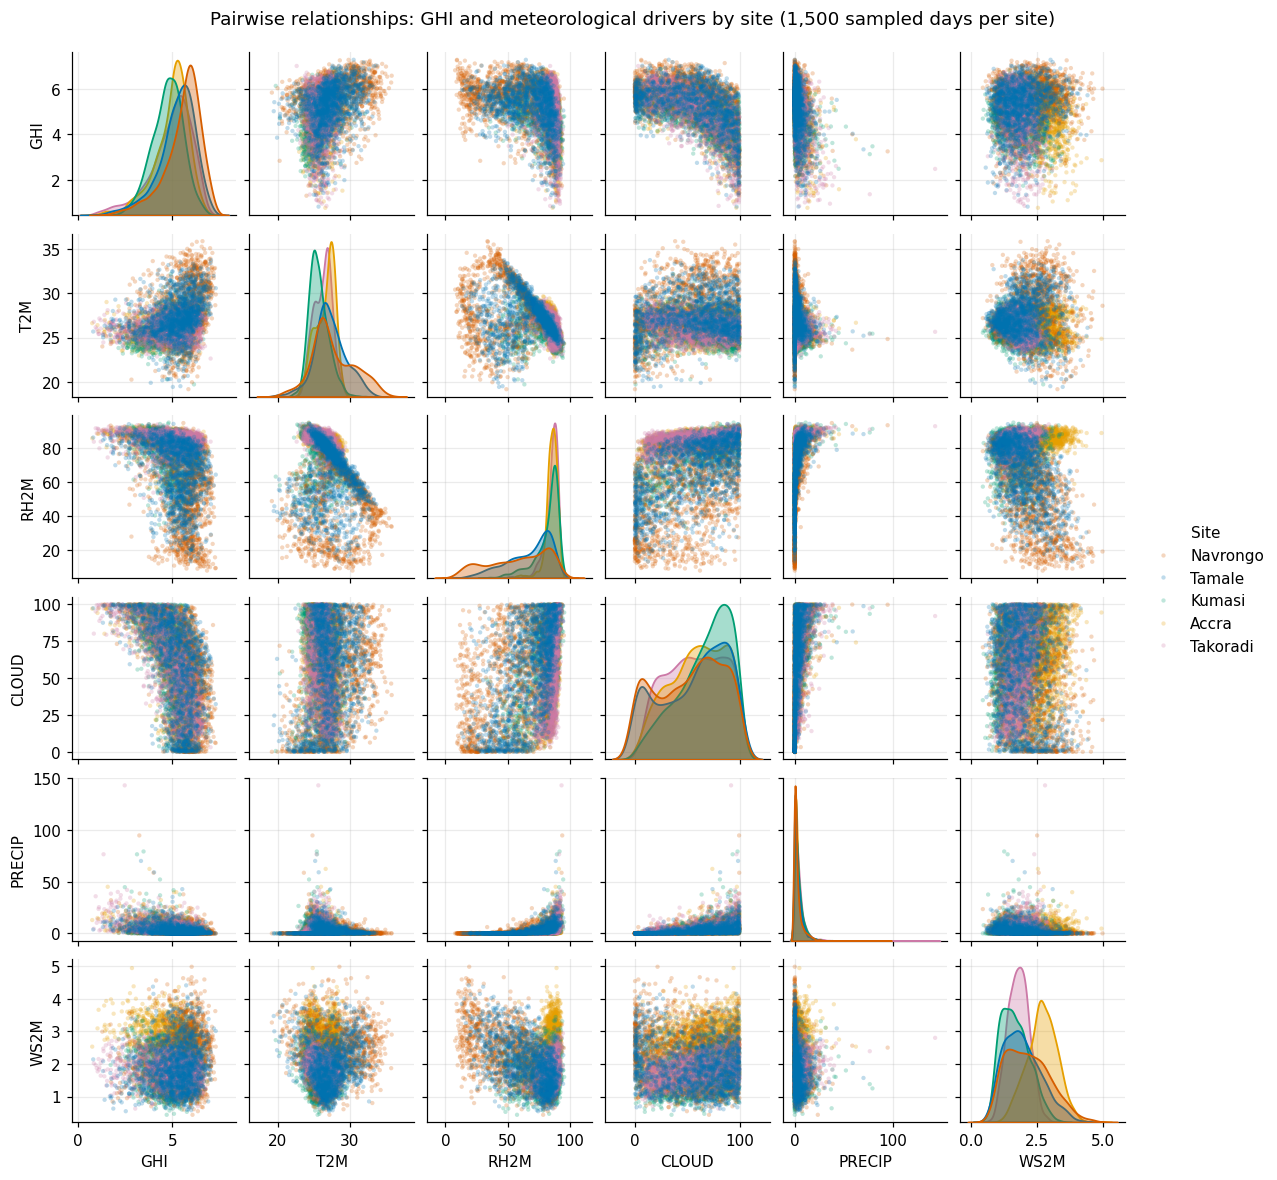

In [12]:
import seaborn as sns

PAIR_VARS = {TARGET: 'GHI', 'T2M': 'T2M', 'RH2M': 'RH2M', 'CLOUD_AMT': 'CLOUD',
             'PRECTOTCORR': 'PRECIP', 'WS2M': 'WS2M'}
sample = df.groupby('site').sample(n=1500, random_state=42)
pp_df = sample[list(PAIR_VARS) + ['site']].rename(columns=PAIR_VARS)
pp_df['Site'] = pp_df['site'].map(SITE_LABEL)

site_palette = {SITE_LABEL[k]: SITE_COLOR[k] for k in SITE_ORDER}
g = sns.pairplot(pp_df.drop(columns='site'), hue='Site',
                 hue_order=[SITE_LABEL[k] for k in SITE_ORDER],
                 palette=site_palette, diag_kind='kde', corner=False,
                 plot_kws={'s': 8, 'alpha': 0.25, 'edgecolor': 'none', 'rasterized': True},
                 diag_kws={'fill': True, 'alpha': 0.35, 'linewidth': 1.2}, height=1.75)
g.figure.suptitle('Pairwise relationships: GHI and meteorological drivers by site '
                  '(1,500 sampled days per site)', y=1.02)
g.figure.savefig(FIGDIR / 'fig_03_9_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation (Figure 3-9).** The pair plot adds three observations the single-relationship figures cannot show. First, the predictors are themselves inter-correlated: temperature and relative humidity form a tight negative band, and cloud amount rises with both humidity and precipitation, so multicollinearity among drivers is real; the VIF screening planned for RQ2 is warranted, and importance rankings should come from permutation and SHAP methods rather than raw regression coefficients. Second, the sites separate most clearly in the driver panels rather than the GHI panels: wind speed nearly isolates Accra (the windiest site, mean 2.7 m/s) from Kumasi (the calmest, 1.6 m/s), and the humidity diagonal splits the broad northern distributions from the coastal sites' narrow peaks near saturation; this is the regime signal available to site-aware models. Third, no bivariate panel shows structure stronger than GHI versus cloud amount, confirming the threshold pattern of §3.7 as the dominant relationship the forecasting models must capture. Precipitation is heavily zero-inflated, which cautions against treating its linear correlation as the full story.

## 3.9 Interannual variability (Figure 3-4)

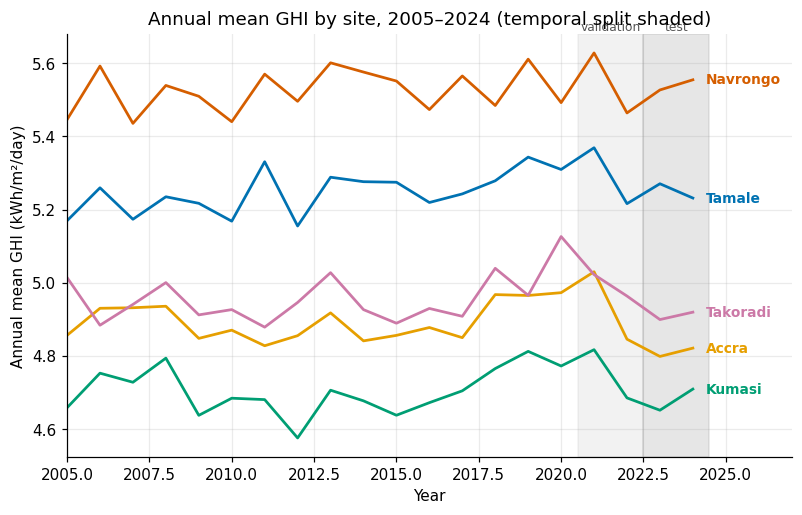

In [13]:
annual = df.groupby(['site', df.index.year])[TARGET].mean().rename_axis(['site', 'year']).reset_index()
fig, ax = plt.subplots(figsize=(8.5, 5))
for key in SITE_ORDER:
    a = annual[annual['site'] == key]
    ax.plot(a['year'], a[TARGET], color=SITE_COLOR[key], lw=1.8)
    ax.annotate(SITE_LABEL[key], xy=(2024, a[TARGET].iloc[-1]), xytext=(2024.4, a[TARGET].iloc[-1]),
                color=SITE_COLOR[key], fontsize=9, fontweight='bold', va='center')
ax.axvspan(2020.5, 2022.5, color='#999', alpha=0.12)
ax.axvspan(2022.5, 2024.5, color='#999', alpha=0.24)
ax.text(2021.5, ax.get_ylim()[1], 'validation', ha='center', va='bottom', fontsize=8, color='#555')
ax.text(2023.5, ax.get_ylim()[1], 'test', ha='center', va='bottom', fontsize=8, color='#555')
ax.set_xlim(2005, 2027)
ax.set_xlabel('Year'); ax.set_ylabel('Annual mean GHI (kWh/m²/day)')
ax.set_title('Annual mean GHI by site, 2005–2024 (temporal split shaded)')
fig.savefig(FIGDIR / 'fig_03_4_annual_means.png')
plt.show()

**Interpretation (Figure 3-4).** Annual means fluctuate inside a narrow ±0.2–0.3
kWh/m²/day band with no visible monotonic trend at any site, and the site ranking is
stable year after year. The validation (2021–2022) and test (2023–2024) windows sit
within the historical range — neither anomalously sunny nor cloudy — so the temporal
split gives the models a fair, representative evaluation period and supports using the
full 20-year record for the sizing simulation.

## 3.10 Consecutive low-sun days (Figure 3-5, RQ4 sizing groundwork)

A day with GHI < 3.5 kWh/m²/day is treated as a *low-sun day* (roughly the level
at which a PV system sized on the long-term mean under-produces). The length of
the longest annual run of consecutive low-sun days drives how many days of
battery autonomy an off-grid system needs.

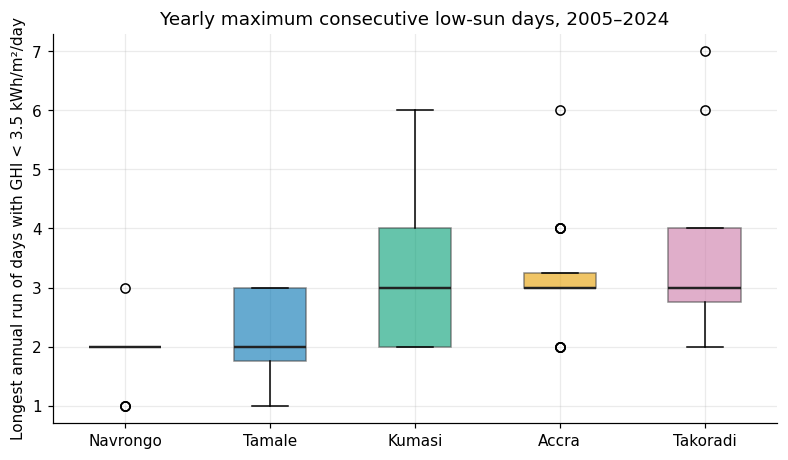

,Site,Median longest run (days/yr),Worst run 2005–2024 (days),Low-sun days/yr (mean)
0,Navrongo,2.0,3,18.4
1,Tamale,2.0,3,22.8
2,Kumasi,3.0,6,29.7
3,Accra,3.0,6,33.0
4,Takoradi,3.0,7,37.2


In [14]:
LOW = 3.5
def runs_per_year(s):
    low = (s < LOW).astype(int)
    grp = (low.diff() != 0).cumsum()
    runs = low.groupby([s.index.year, grp]).agg(['sum', 'first'])
    runs = runs[runs['first'] == 1]['sum']
    return runs.groupby(level=0).max().reindex(range(2005, 2025), fill_value=0)

run_rows = {}
for key in SITE_ORDER:
    s = df.loc[df['site'] == key, TARGET].dropna()
    run_rows[key] = runs_per_year(s)
run_df = pd.DataFrame(run_rows)

fig, ax = plt.subplots(figsize=(8.5, 4.6))
bp = ax.boxplot([run_df[k] for k in SITE_ORDER], patch_artist=True, widths=0.5, showfliers=True)
for patch, key in zip(bp['boxes'], SITE_ORDER):
    patch.set_facecolor(SITE_COLOR[key]); patch.set_alpha(0.6); patch.set_edgecolor('#444')
for med in bp['medians']:
    med.set_color('#222'); med.set_linewidth(1.6)
ax.set_xticklabels([SITE_LABEL[k] for k in SITE_ORDER])
ax.set_ylabel(f'Longest annual run of days with GHI < {LOW} kWh/m²/day')
ax.set_title('Yearly maximum consecutive low-sun days, 2005–2024')
fig.savefig(FIGDIR / 'fig_03_5_low_sun_runs.png')
plt.show()

low_summary = pd.DataFrame({
    'Site': [SITE_LABEL[k] for k in SITE_ORDER],
    'Median longest run (days/yr)': [run_df[k].median() for k in SITE_ORDER],
    'Worst run 2005–2024 (days)': [run_df[k].max() for k in SITE_ORDER],
    'Low-sun days/yr (mean)': [float((df.loc[df['site'] == k, TARGET] < LOW).groupby(
        df.loc[df['site'] == k].index.year).sum().mean()) for k in SITE_ORDER]}).round(1)
low_summary.to_csv(RESULTS / 'eda_low_sun_runs.csv', index=False)
low_summary

**Interpretation (Figure 3-5).** Low-sun spells are roughly twice as severe in the
south: the median longest annual run is 2 consecutive days below 3.5 kWh/m²/day at
Navrongo/Tamale versus 3 days at the three southern sites, and the 20-year worst case
grows from 3 days (north) to 6–7 days (Kumasi, Accra, Takoradi). Total exposure shows
the same gradient — on average ≈ 18 low-sun days/year at Navrongo versus ≈ 37 at
Takoradi. This is direct groundwork for RQ4: a fixed days-of-autonomy rule calibrated
in the north would under-protect a coastal household, which is exactly the
zone-specific sizing gap the capstone addresses.

## 3.11 Day-type composition by site and season (Figure 3-8)

Days are classed as low (< 3.5), moderate (3.5–5.5), or high (> 5.5 kWh/m²/day).
The 100% stacked bars turn the distributions into the proportions that matter for
sizing: how often a system must ride through low-sun days, and when.

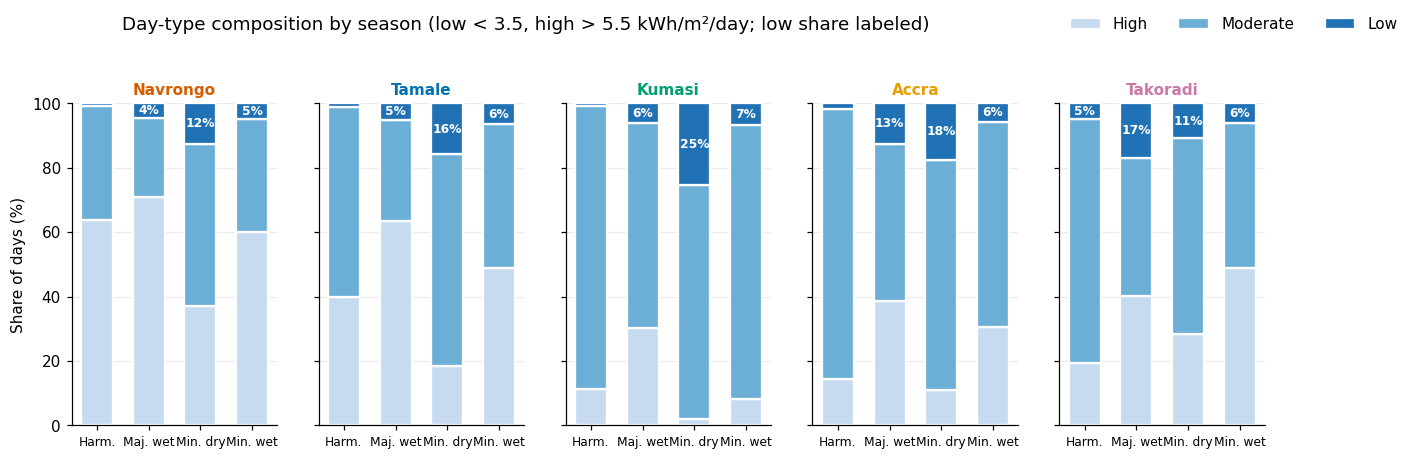

In [15]:
LOW_T, HIGH_T = 3.5, 5.5
CAT_COLORS = {'high': '#C6DBEF', 'moderate': '#6BAED6', 'low': '#2171B5'}

def day_type(v):
    return np.where(v < LOW_T, 'low', np.where(v > HIGH_T, 'high', 'moderate'))

df['_day_type'] = day_type(df[TARGET])
comp = (df.groupby(['site', 'season', '_day_type']).size()
          .rename('n').reset_index())
comp['share'] = comp.groupby(['site', 'season'])['n'].transform(lambda s: s / s.sum())
comp.to_csv(RESULTS / 'eda_day_type_composition.csv', index=False)

fig, axes = plt.subplots(1, 5, figsize=(14, 3.8), sharey=True)
for ax, key in zip(axes, SITE_ORDER):
    bottoms = np.zeros(len(SEASON_ORDER))
    for cat in ['high', 'moderate', 'low']:
        vals = []
        for s in SEASON_ORDER:
            m = comp[(comp['site'] == key) & (comp['season'] == s) & (comp['_day_type'] == cat)]
            vals.append(float(m['share'].iloc[0]) if len(m) else 0.0)
        vals = np.array(vals) * 100
        ax.bar(range(len(SEASON_ORDER)), vals, bottom=bottoms, color=CAT_COLORS[cat],
               width=0.62, edgecolor='white', linewidth=1.5,
               label=cat.capitalize() if key == SITE_ORDER[0] else None)
        if cat == 'low':
            for x, (b, v) in enumerate(zip(bottoms, vals)):
                if v >= 3:
                    ax.text(x, b + v / 2, f'{v:.0f}%', ha='center', va='center',
                            fontsize=8, color='white', fontweight='bold')
        bottoms += vals
    ax.set_xticks(range(len(SEASON_ORDER)))
    ax.set_xticklabels(['Harm.', 'Maj. wet', 'Min. dry', 'Min. wet'], fontsize=8)
    ax.set_title(SITE_LABEL[key], fontsize=10, color=SITE_COLOR[key], fontweight='bold')
axes[0].set_ylabel('Share of days (%)')
axes[0].set_ylim(0, 100)
fig.legend(loc='upper right', bbox_to_anchor=(0.995, 1.12), ncol=3, frameon=False)
fig.suptitle('Day-type composition by season (low < 3.5, high > 5.5 kWh/m²/day; low share labeled)',
             y=1.09, x=0.42)
fig.savefig(FIGDIR / 'fig_03_8_day_type_composition.png')
plt.show()

**Interpretation (Figure 3-8).** The stacked composition turns the distributions into sizing-relevant proportions and reveals when the low-sun exposure occurs. Low-sun days are rare everywhere in the Harmattan (0–5% of days) and concentrate in the mid-year cloudy season, but with sharply different intensity by zone: the minor-dry (Jul–Aug) low-sun share reaches 25% at Kumasi and 18% at Accra, versus 12% at Navrongo, while at Takoradi the burden peaks in the major wet season (17%). The high-sun share tells the complementary story: Navrongo enjoys high-sun conditions on 60–71% of days outside the minor dry season, whereas Kumasi exceeds the 5.5 kWh/m²/day threshold on at most 30% of days (major wet) and on only 2% in the minor dry. For RQ4 this means southern systems must be engineered around a season in which roughly one day in four to six under-produces, and it confirms that a single national autonomy rule cannot serve both Navrongo and Kumasi. Composition table saved as results/eda_day_type_composition.csv.

## 3.12 EDA insight summary

| Figure/Table | What it shows | Key insight | Why it matters (RQ link) | Decision / next step |
|---|---|---|---|---|
| Table 3.1 (`eda_summary_stats.csv`) | Per-site GHI distribution | North–south mean gradient (5.53 → 4.71); Takoradi most variable | Confirms zone contrast motivating site design (RQ1/RQ3) | Keep all five sites; report per-site metrics |
| Table 3.2 (`eda_driver_summary_stats.csv`) | Univariate driver statistics | Humidity separates regimes (85% coast vs. 58% north; SD 24 vs. 5) | Regime signal available to models (RQ1/RQ2) | Keep all five drivers as features |
| Fig 3-6 (`fig_03_6`) | Univariate GHI distributions | All sites left-skewed (−0.41 to −1.17); risk in lower tail | Tail days dominate RMSE (RQ1); mean overstates resource (RQ4) | Evaluate errors on tail days; size on lower tail |
| Fig 3-1 | Monthly climatology | Bimodal cycle; wet-season trough far deeper in the south | Seasonality is the dominant signal (RQ1); seasonal stratification needed (RQ3) | Fourier/day-of-year features retained in all models |
| Fig 3-2 | Seasonal distributions | Season effects strongest at coastal/forest sites | Predicts season-dependent errors (RQ3) | Stratify validation metrics by season in 06 |
| Fig 3-3 (`eda_driver_correlations.csv`) | Driver correlations | Cloud amount dominates everywhere (−0.44…−0.68); wind flips sign N vs S | Prior expectation for feature importance (RQ2) | Compare against SHAP rankings in 06 |
| Fig 3-7 (`fig_03_7`) | GHI vs. cloud amount (bivariate) | Nonlinear threshold shape: flat to ~40–50% cloud, then steep decline | Justifies nonlinear tree ensembles (RQ1); sharpens SHAP expectation (RQ2) | Retain RF/XGBoost over linear models |
| Fig 3-9 (`fig_03_9`) | Pair plot, all variable pairs | Drivers inter-correlated (T2M–RH2M band); sites separate in driver panels | Multicollinearity → use permutation/SHAP, VIF screening (RQ2) | Rank importance with SHAP, not coefficients |
| Fig 3-4 | Annual means | No trend; val/test years typical | Split fairness; 20-yr record usable for sizing (RQ4) | Proceed with fixed temporal split |
| Fig 3-5 (`eda_low_sun_runs.csv`) | Consecutive low-sun runs | Worst runs 3 d (north) vs 6–7 d (south) | Zone-specific autonomy need (RQ4) | Energy-balance simulation must be per-zone |
| Fig 3-8 (`eda_day_type_composition.csv`) | Day-type composition by season | Minor-dry low-sun share: 25% Kumasi, 18% Accra vs 12% Navrongo | Low-sun exposure is seasonal and zonal (RQ3/RQ4) | Size against the worst season, per zone |